In [1]:
import numpy as np

def Bz_analytic(z, I, R, mu0=4e-7*np.pi):
    """
    Магнитное поле (ось z) от токового кольца радиусом R с током I 
    в точке (0,0,z) по известной формуле.
    mu0 = 4π×10^-7 (Гн/м) -- магнитная постоянная в СИ
    """
    return (mu0 * I * R**2) / (2.0 * (R**2 + z**2)**(3/2))

# Пример использования:
I = 1.0      # Ток, А
R = 1.0      # Радиус кольца, м
z0 = 0.5     # Точка наблюдения по оси z
b_analytic = Bz_analytic(z0, I, R)
print("Аналитическое Bz =", b_analytic, "Тл (примерно)")


Аналитическое Bz = 4.4958814278660644e-07 Тл (примерно)


In [2]:
import numpy as np

def dBz_biotsavart(phi, z0, I, R, mu0=4e-7*np.pi):
    """
    Вычисляет вклад dBz от *малого* участка токового кольца,
    соответствующего углу phi в плоскости (x,y).
    
    Возвращает dBz (скаляр).
    """
    # Координаты элемента кольца:
    x_prime = R * np.cos(phi)
    y_prime = R * np.sin(phi)
    z_prime = 0.0
    
    # Вектор R (из источника в точку наблюдения):
    Rx = -x_prime
    Ry = -y_prime
    Rz = z0
    
    # dl = ( -R sin(phi),  R cos(phi),  0 ) dphi
    dlx = -R * np.sin(phi)
    dly =  R * np.cos(phi)
    dlz =  0.0
    
    # Векторное произведение dl x R:
    # (dl_x, dl_y, dl_z) x (Rx, Ry, Rz)
    cross_x = dly*Rz - dlz*Ry
    cross_y = dlz*Rx - dlx*Rz
    cross_z = dlx*Ry - dly*Rx
    
    # Модуль R^3:
    R_mag = np.sqrt(Rx*Rx + Ry*Ry + Rz*Rz)
    R_cubed = R_mag**3
    
    # dB = (mu0 / 4π) * (I * cross / R^3)
    # Нас интересует только z-компонента:
    dBz = (mu0/(4*np.pi)) * I * (cross_z / R_cubed)
    
    return dBz

def Bz_monte_carlo(z0, I, R, n_samples=100000, mu0=4e-7*np.pi):
    """
    Оценивает Bz методом Монте-Карло:
    1) Случайно генерируем углы phi в [0, 2π].
    2) Суммируем dBz (с учётом того, что нам нужно интегральное значение).
       Однако мы не берём маленький "dphi" отдельно, а используем усреднение 
       и умножаем на 2π (как в методе Монте-Карло).
    """
    # Генерируем случайные углы:
    phi_random = 2*np.pi * np.random.rand(n_samples)
    
    # Считаем сумму вкладов dBz(phi).
    # Но обратите внимание, что формула dBz_biotsavart предполагает *уже* приписанное dphi
    # (либо придётся умножать на dphi). Есть разные способы "учёта":
    # 1) Можно считать, что dBz_biotsavart() возвращает вклад без умножения на dphi,
    #    тогда надо умножить на dphi = 2π / n_samples для каждого сэмпла.
    #
    # Для наглядности сделаем так: dBz_biotsavart() вернёт вклад *на единицу dphi*,
    # и мы явно умножим на (2π / n_samples).
    
    dBz_values = dBz_biotsavart(phi_random, z0, I, R, mu0)
    
    # Среднее по всем случайным точкам (это среднее значение функции),
    # а интеграл по phi от 0 до 2π будет это среднее * 2π.
    mean_dBz = np.mean(dBz_values)
    
    # Тогда общее поле (интеграл) есть:
    Bz_total = mean_dBz * 2.0 * np.pi
    
    return Bz_total


In [3]:
np.random.seed(42)  # фиксируем seed для воспроизводимости
    
I = 1.0      # Ток, А
R = 1.0      # Радиус кольца, м
z0 = 0.5     # Точка наблюдения
mu0 = 4e-7*np.pi

# Аналитическое решение:
b_analytic = Bz_analytic(z0, I, R, mu0)
print("Аналитическое Bz =", b_analytic)

# Монте-Карло (без специальных весов, просто равномерная выборка):
n_samples = 100000
b_monte = Bz_monte_carlo(z0, I, R, n_samples=n_samples, mu0=mu0)
print("Монте-Карло Bz (n_samples={:d}) = {:.6e}".format(n_samples, b_monte))
print("Разница =", abs(b_monte - b_analytic))


Аналитическое Bz = 4.4958814278660644e-07
Монте-Карло Bz (n_samples=100000) = 4.495881e-07
Разница = 1.0587911840678754e-22


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Аналитическое решение: E_z на оси кольца
def Ez_analytic(z, Q, R, eps0=8.8541878128e-12):
    """
    E_z(z) для кольца радиуса R с равномерным зарядом Q.
    Формула: (1/(4 pi eps0)) * Q * z / (z^2 + R^2)^(3/2)
    """
    return (1/(4*np.pi*eps0)) * Q * z / ( (z**2 + R**2)**(1.5) )

# 2) Численное решение методом Монте-Карло
def Ez_monte_carlo(z, Q, R, n_samples=100000, eps0=8.8541878128e-12, seed=None):
    """
    Оценивает E_z в точке (0,0,z) от кольца (радиус R, суммарный заряд Q),
    равномерно распределённого по углу phi в [0, 2π].
    Использует простой метод Монте-Карло (равномерная выборка phi).
    """
    if seed is not None:
        np.random.seed(seed)
        
    # Генерируем случайные углы (равномерно от 0 до 2π):
    phi_random = 2.0 * np.pi * np.random.rand(n_samples)
    
    # Координаты элемента кольца:
    x_prime = R * np.cos(phi_random)
    y_prime = R * np.sin(phi_random)
    z_prime = 0.0  # кольцо в плоскости xy
    
    # Вектор R = (0 - x', 0 - y', z - 0)
    Rx = -x_prime
    Ry = -y_prime
    Rz = z
    
    # Расстояние |R|:
    R_mag = np.sqrt(Rx**2 + Ry**2 + Rz**2)
    
    # dE = (1/(4 pi eps0)) * (dq / R^2) * R_hat
    # Но R_hat = R / |R|, а dq = (Q/(2π)) * dphi
    # Здесь "dphi" ~ (2π / n_samples).
    #
    # Удобно сделать так:
    # - Сначала вычислим "Edz_ без умножения на dphi"
    # - Потом умножим результат на (Q / 2π) * (1/(4π eps0)) * (2π / n_samples)
    #   Тем самым учтём весь заряд Q и всю "площадь" углов.
    
    # Вклад в E_z от *одного* элемента (без учёта dphi и dq ещё):
    #   dE_z = (1/|R|^3) * Rz
    # (потому что (R/|R|) = (Rx, Ry, Rz)/R_mag, и умножение на 1/R^2 даёт 1/R^3)
    
    dE_z_single = Rz / (R_mag**3)
    
    # Усредняем по всем случайным углам:
    mean_dE_z = np.mean(dE_z_single)
    
    # Теперь учтём все постоянные множители:
    # dq = Q/(2π) * dphi => "средний" dphi ~ (2π / n_samples)
    # => итого multiply = Q/(2π) * (2π / n_samples) = Q / n_samples
    # И ещё коэффициент (1/(4π eps0)).
    
    # Итого:
    # E_z = (1/(4π eps0)) * (Q / n_samples) * sum_over_i( (1/|R|^3) * Rz ) 
    # Но sum_over_i(...) ~ n_samples * mean_dE_z, поэтому получается:
    # E_z = (1/(4π eps0)) * Q * mean_dE_z
    
    E_z = (1/(4*np.pi*eps0)) * Q * mean_dE_z
    
    return E_z

def main():
    # Параметры кольца и эксперимента
    Q = 1.0e-6             # общий заряд, Кл (пример)
    R = 1.0                # радиус кольца, м
    eps0 = 8.8541878128e-12
    
    # Сформируем набор точек z, на которых хотим вычислить E_z
    z_values = np.linspace(-2*R, 2*R, 51)  # от -2R до 2R
    E_analytic = []
    E_monte = []
    
    n_samples = 200000  # кол-во выборок в Монте-Карло
    
    for z0 in z_values:
        # Аналитика:
        E_analytic.append(Ez_analytic(z0, Q, R, eps0))
        # Монте-Карло:
        E_monte.append(Ez_monte_carlo(z0, Q, R, n_samples=n_samples, eps0=eps0))
    
    # Переведём списки в массивы (для удобства):
    E_analytic = np.array(E_analytic)
    E_monte = np.array(E_monte)
    
    # Печать нескольких точек для сравнения:
    print("z\t   E_z_analytic\t   E_z_MonteCarlo")
    for i in range(0, len(z_values), 10):
        print(f"{z_values[i]:.3f}\t {E_analytic[i]:.5e}\t {E_monte[i]:.5e}")
    
    # 3) Визуализация (график E_z(z))
    plt.figure(figsize=(8,6))
    plt.plot(z_values, E_analytic, 'r-', label="Аналитическое решение")
    plt.plot(z_values, E_monte, 'bo', markersize=4, label="Метод Монте-Карло")
    
    plt.axhline(0, color='k', linewidth=0.8)  # Линия y=0 для ориентира
    plt.xlabel("z, м")
    plt.ylabel("E_z, В/м")
    plt.title("Сравнение E_z на оси кольца (радиус R) - аналитика vs. Монте-Карло")
    plt.legend()
    plt.grid(True)
    plt.show()


z	   E_z_analytic	   E_z_MonteCarlo
-2.000	 -1.60774e+03	 -1.60774e+03
-1.200	 -2.82968e+03	 -2.82968e+03
-0.400	 -2.87749e+03	 -2.87749e+03
0.400	 2.87749e+03	 2.87749e+03
1.200	 2.82968e+03	 2.82968e+03
2.000	 1.60774e+03	 1.60774e+03


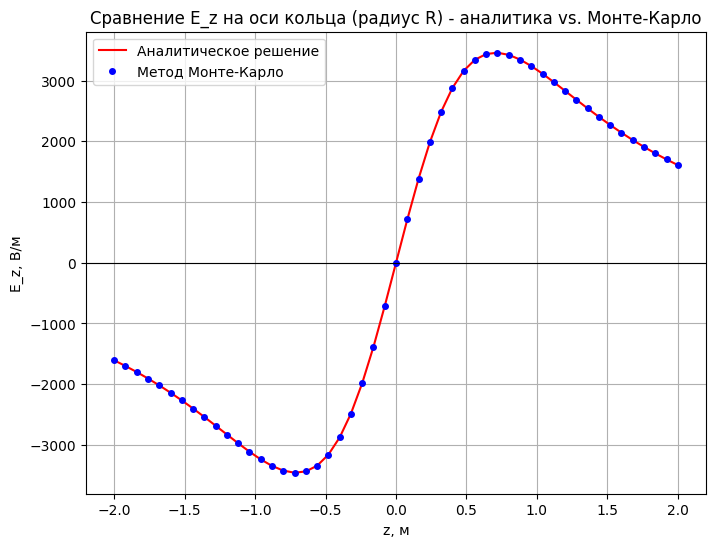

In [5]:
main()